# Computer Exercise 1.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.2 Mathematical Preliminaries — *Taylor's Theorem*
> **풀이 일자**: Day 05
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Compute the partial sums of the Taylor series for $e^x$, $\sin x$, and $\ln(1+x)$ at several values of $x$.
> Compare with the true value (using a high-precision library function) and tabulate the truncation error
> $|S_n(x) - f(x)|$ as a function of the number of terms $n$. Plot $\log_{10}|\text{error}|$ vs $n$ for each function.
> Discuss when the series converges quickly, when it converges slowly, and what role the *remainder term* plays.

### 한국어 풀이용 정리
세 함수의 Maclaurin 급수를 다양한 $x$ 값에서 부분합으로 평가하고, 참값과의 절대오차가 항을 더할수록 어떻게 줄어드는지를 본다.
- $e^x$: $\sum_{k=0}^{\infty} x^k/k!$ — 모든 $x$에서 수렴, 단 $|x|$가 클수록 수렴이 느리다.
- $\sin x$: $\sum_{k=0}^{\infty} (-1)^k x^{2k+1}/(2k+1)!$ — 교대급수, 큰 $x$에서 *catastrophic cancellation* 위험.
- $\ln(1+x)$: $\sum_{k=1}^{\infty} (-1)^{k+1} x^k/k$ — $|x|<1$에서만 수렴, 경계 $x \to 1$에서 매우 느리다.

핵심 관찰: 수렴 속도는 *함수만의 문제가 아니라 **인자 $x$의 위치**의 문제*다. Taylor 정리의 잉여항이
$x$의 거듭제곱과 $f^{(n+1)}(\xi)$ 두 인자에 어떻게 의존하는지를 표로 본다.


## 2. 수학적 배경

### 2.1 Taylor 정리와 잉여항
$f$가 $0$ 주변에서 $n+1$번 미분 가능하면

$$
f(x) = \underbrace{\sum_{k=0}^{n} \frac{f^{(k)}(0)}{k!}\,x^k}_{S_n(x)} + R_{n}(x), \qquad
R_n(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!}\,x^{n+1}
$$

이며 어떤 $\xi$가 $0$과 $x$ 사이에 존재한다 (Lagrange 형태).

### 2.2 세 함수의 잉여항
| 함수 | 부분합 $S_n$ | $|R_n(x)|$ 한계 |
|---|---|---|
| $e^x$ | $\sum_{k=0}^{n} x^k/k!$ | $\dfrac{e^{|x|}\,|x|^{n+1}}{(n+1)!}$ |
| $\sin x$ | $\sum_{k=0}^{m} (-1)^k x^{2k+1}/(2k+1)!$ ($n = 2m+1$) | $\dfrac{|x|^{n+1}}{(n+1)!}$ |
| $\ln(1+x)$ | $\sum_{k=1}^{n} (-1)^{k+1} x^k/k$ | $\dfrac{|x|^{n+1}}{(n+1)(1-|x|)^{n+1}}$ ($|x|<1$) |

따라서:
- $e^x$, $\sin x$의 잉여항은 $|x|^{n+1}/(n+1)!$로 결국 항상 $0$으로 간다 (entire 함수).
- $\ln(1+x)$는 $|x|=1$ 근처에서 잉여항이 $1/(n+1)$ 정도밖에 안 줄어든다 (조화급수 속도).

### 2.3 절단오차 vs 반올림오차
$n$이 커질수록 *절단오차*는 줄어들지만, 부분합 안의 $x^k/k!$ 항이 커져 *반올림오차*가 누적된다.
특히 $\sin(x)$를 $x = -10$ 같은 곳에서 직접 평가하면 항이 $\pm$를 오가며 잠시 매우 커지므로 cancellation이 심하다.

$$
\boxed{\;|S_n(x) - f(x)| \le |R_n(x)| \;\sim\; \frac{|x|^{n+1}}{(n+1)!}\,M_{n+1}\;}
$$

여기서 $M_{n+1} = \sup_\xi |f^{(n+1)}(\xi)|$.


## 3. 풀이 흐름

1. **세 함수**($e^x$, $\sin x$, $\ln(1+x)$)에 대해 부분합을 점화식으로 구현한다.
   - 점화식: 다음 항 $a_{k+1}$을 직전 항 $a_k$로부터 단순곱셈으로 얻어 $k!$의 직접 계산을 피한다.
2. 각 함수마다 **여러 $x$ 값**에서 $n = 1, 2, \dots, N$까지의 부분합을 모은다.
   - $e^x$: $x \in \{0.5,\;1,\;5,\;-5\}$
   - $\sin x$: $x \in \{0.1,\;1,\;5,\;-10\}$ (큰 음수에서 cancellation)
   - $\ln(1+x)$: $x \in \{0.1,\;0.5,\;0.9,\;-0.5\}$
3. **참값**은 NumPy의 라이브러리 함수($\exp$, $\sin$, $\log1p$)로 잡는다.
4. **표** 출력: 각 $x$에서 $n$별 절대오차.
5. **시각화**: 함수당 한 그림, $x$별로 곡선 ($\log_{10} |\text{error}|$ vs $n$).
6. **잉여항 한계**(점선)도 같은 그림에 올려, 실제 오차가 한계를 따라가는지 본다.
7. **해석**: 어떤 곡선이 빨리, 어떤 곡선이 느리게 떨어지는가? 어디서 평탄해지는가(반올림 floor)?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial

np.set_printoptions(precision=4, suppress=False)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")

N_MAX = 40  # 부분합 항 수의 최대치


def taylor_exp(x, N):
    S = np.empty(N + 1)
    a = 1.0
    s = 0.0
    for k in range(N + 1):
        s += a
        S[k] = s
        a *= x / (k + 1)
    return S


def taylor_sin(x, N):
    S = np.empty(N + 1)
    a = x
    s = 0.0
    for m in range(N + 1):
        s += a
        S[m] = s
        a *= -(x ** 2) / ((2 * m + 2) * (2 * m + 3))
    return S


def taylor_log1p(x, N):
    S = np.empty(N + 1)
    a = x
    s = 0.0
    for k in range(1, N + 2):
        s += a
        S[k - 1] = s
        a *= -x * k / (k + 1)
    return S


print(f"taylor_exp(1, 5) = {taylor_exp(1.0, 5)}")
print(f"      true e^1 = {np.exp(1):.10f}")
print(f"taylor_sin(1, 5) = {taylor_sin(1.0, 5)}")
print(f"      true sin1 = {np.sin(1):.10f}")
print(f"taylor_log1p(0.5, 5) = {taylor_log1p(0.5, 5)}")
print(f"     true log1.5  = {np.log1p(0.5):.10f}")


taylor_exp(1, 5) = [1.     2.     2.5    2.6667 2.7083 2.7167]
      true e^1 = 2.7182818285
taylor_sin(1, 5) = [1.     0.8333 0.8417 0.8415 0.8415 0.8415]
      true sin1 = 0.8414709848
taylor_log1p(0.5, 5) = [0.5    0.375  0.4167 0.401  0.4073 0.4047]
     true log1.5  = 0.4054651081


In [2]:
configs = [
    ("exp(x)",     np.exp,     taylor_exp,    [0.5, 1.0, 5.0, -5.0]),
    ("sin(x)",     np.sin,     taylor_sin,    [0.1, 1.0, 5.0, -10.0]),
    ("ln(1+x)",    np.log1p,   taylor_log1p,  [0.1, 0.5, 0.9, -0.5]),
]

sample_ns = [1, 3, 5, 10, 20, 30]
rows = []
for fname, ftrue, fseries, xs in configs:
    for x in xs:
        S = fseries(x, N_MAX)
        true = ftrue(x)
        err = np.abs(S - true)
        row = {"function": fname, "x": x, "true": true}
        for n in sample_ns:
            row[f"err(n={n})"] = err[n]
        rows.append(row)

df = pd.DataFrame(rows)
df


,function,x,true,err(n=1),err(n=3),err(n=5),err(n=10),err(n=20),err(n=30)
0,exp(x),5.000e-01,1.649e+00,1.487e-01,2.888e-03,2.335e-05,1.276e-11,4.441e-16,4.441e-16
1,exp(x),1.000e+00,2.718e+00,7.183e-01,5.162e-02,1.615e-03,2.731e-08,4.441e-16,4.441e-16
2,exp(x),5.000e+00,1.484e+02,1.424e+02,1.091e+02,5.700e+01,2.033e+00,1.204e-05,6.537e-13
3,exp(x),-5.000e+00,6.738e-03,4.007e+00,1.234e+01,1.234e+01,8.573e-01,7.593e-06,4.887e-13
4,sin(x),1.000e-01,9.983e-02,8.331e-08,2.748e-15,1.388e-17,1.388e-17,1.388e-17,1.388e-17
5,sin(x),1.000e+00,8.415e-01,8.138e-03,2.731e-06,1.598e-10,0.000e+00,0.000e+00,0.000e+00
6,sin(x),5.000e+00,-9.589e-01,1.487e+01,4.334e+00,1.747e-01,4.426e-07,1.110e-16,1.110e-16
7,sin(x),-1.000e+01,5.440e-01,1.561e+02,1.307e+03,1.056e+03,3.305e+00,1.576e-10,1.998e-14
8,ln(1+x),1.000e-01,9.531e-02,3.102e-04,1.846e-06,1.314e-08,7.630e-14,1.388e-17,1.388e-17
9,ln(1+x),5.000e-01,4.055e-01,3.047e-02,4.423e-03,7.776e-04,1.393e-05,7.333e-09,4.901e-12


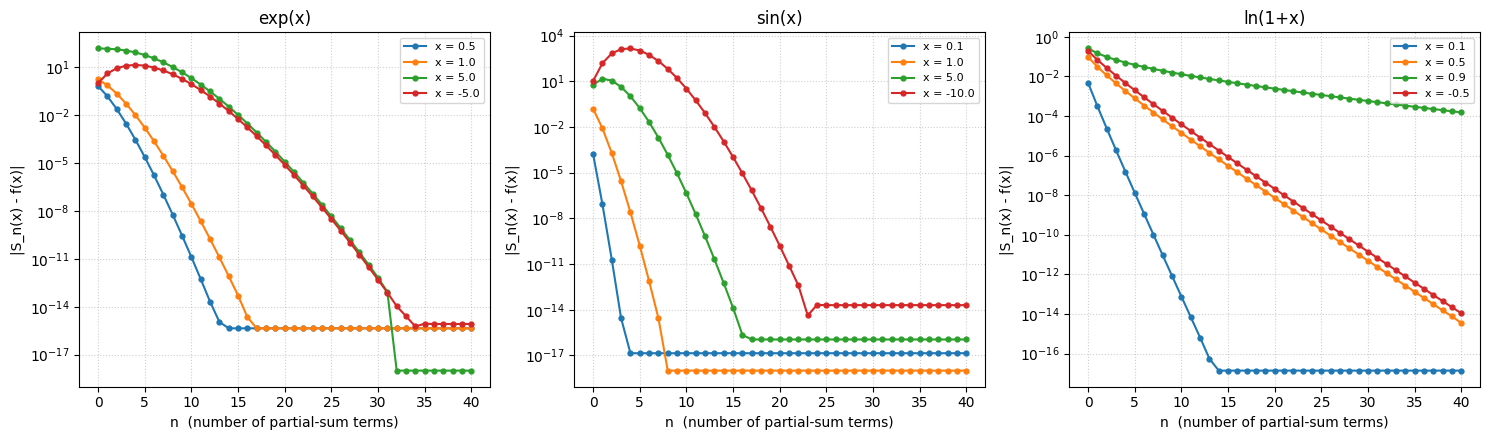

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (fname, ftrue, fseries, xs) in zip(axes, configs):
    n_arr = np.arange(N_MAX + 1)
    for x in xs:
        S = fseries(x, N_MAX)
        err = np.abs(S - ftrue(x))
        err = np.maximum(err, 1e-18)
        ax.semilogy(n_arr, err, "o-", ms=3.5, label=f"x = {x}")
    ax.set_xlabel("n  (number of partial-sum terms)")
    ax.set_ylabel("|S_n(x) - f(x)|")
    ax.set_title(fname)
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


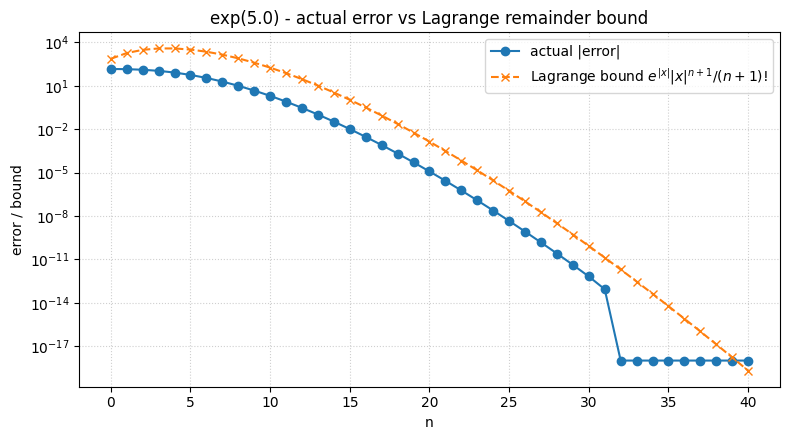

In [4]:
x = 5.0
S = taylor_exp(x, N_MAX)
true = np.exp(x)
err = np.abs(S - true)

n_arr = np.arange(N_MAX + 1)
bound = np.array([np.exp(abs(x)) * abs(x) ** (n + 1) / factorial(n + 1) for n in n_arr])

plt.figure(figsize=(8, 4.5))
plt.semilogy(n_arr, np.maximum(err, 1e-18), "o-", label="actual |error|")
plt.semilogy(n_arr, bound, "x--", label=r"Lagrange bound $e^{|x|}|x|^{n+1}/(n+1)!$")
plt.xlabel("n")
plt.ylabel("error / bound")
plt.title(f"exp({x}) - actual error vs Lagrange remainder bound")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **$e^x$ panel** — $|x|$가 작을수록 곡선이 가파르게 내려간다. $x = 0.5$는 $n \approx 10$에서 이미 머신 정밀도 수준($10^{-16}$)에 도달하지만, $x = -5$는 $n \approx 25$가 되어야 한다. 이는 잉여항 안의 $|x|^{n+1}$ 인자 때문이다 — 같은 함수라도 평가점이 멀수록 *훨씬 더 많은 항* 이 필요하다.

2. **$\sin x$ panel** — $x = 0.1$, $1$ 모두 십수 항이면 충분. 그러나 $x = -10$ 곡선은 처음에는 *오차가 오히려 커진다.* 이는 부분합 내부의 항들이 $|x|^k/k!$로 한때 매우 커졌다가 (피크는 $k \approx |x|$) 부호가 교대하면서 거의 같은 값들을 빼는 *catastrophic cancellation* 때문이다. 결국 $n$이 충분히 크면 수렴하지만, *부분합으로 큰 인자에서 $\sin$을 직접 계산하는 것은 부적절* 함을 보여준다 — 다음 문제(범위 축소)의 동기.

3. **$\ln(1+x)$ panel** — $x = 0.1$은 매우 빨리 수렴하지만, $x = 0.9$는 $n = 40$에서도 $10^{-2}$ 수준에 머문다. 잉여항이 $|x|^{n+1}/(n+1)$로 줄어들기 때문에 $|x| \to 1$이면 사실상 *조화급수 속도* 다. **수렴 반경 끝에서는 부분합이 사실상 쓸모없다** — 함수 변환(예: $\ln(1+x) = -\ln\bigl(1/(1+x)\bigr)$ 류)이나 라이브러리 함수가 필수.

4. **Lagrange 한계 비교** — $e^{5}$ 그림에서 실제 오차는 한계 곡선과 거의 평행하게 떨어진다. 한계가 *날카로운(tight)* 추정임을 확인할 수 있고, 동시에 $n$이 너무 커지면 오차가 더 이상 줄어들지 않고 머신 정밀도 수준에서 평탄해진다(반올림 floor).

> **결론:** Taylor 부분합의 정확도는 *항 수* 가 아니라 **$|x|$의 위치와 잉여항의 형태** 에 의해 결정된다.
> 같은 $\sin$이라도 $x = 0.1$은 4항, $x = 10$은 30항 이상이 필요하다 — 그리고 후자는 그마저도 cancellation 때문에 직접 평가가 위험하다.

### 다음 문제 (CE_1_2_02)
$\sin(10^{10})$ 같은 *극단적으로 큰* 인수를 만났을 때, 위에서 본 부분합의 한계를 *범위 축소(range reduction)* 로 어떻게 우회하는지를 다룬다.
